# Bank Loan Analysis

### Import Libraries

In [2]:
!pip install pandas numpy matplotlib seaborn plotly


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
!pip install pandas numpy matplotlib seaborn plotly


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import plotly.express as px

In [5]:
!pip install openpyxl


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
df = pd.read_excel("C:/Users/roddi/Documents/Data Analytics/Loan Assessment/financial_loan.xlsx")

In [8]:
df.head()

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,1077430,GA,INDIVIDUAL,< 1 year,Ryder,C,RENT,2021-02-11,2021-09-13,2021-04-13,...,C4,60 months,Source Verified,30000.0,0.0100,59.83,0.1527,2500,4,1009
1,1072053,CA,INDIVIDUAL,9 years,MKC Accounting,E,RENT,2021-01-01,2021-12-14,2021-01-15,...,E1,36 months,Source Verified,48000.0,0.0535,109.43,0.1864,3000,4,3939
2,1069243,CA,INDIVIDUAL,4 years,Chemat Technology Inc,C,RENT,2021-01-05,2021-12-12,2021-01-09,...,C5,36 months,Not Verified,50000.0,0.2088,421.65,0.1596,12000,11,3522
3,1041756,TX,INDIVIDUAL,< 1 year,barnes distribution,B,MORTGAGE,2021-02-25,2021-12-12,2021-03-12,...,B2,60 months,Source Verified,42000.0,0.0540,97.06,0.1065,4500,9,4911
4,1068350,IL,INDIVIDUAL,10+ years,J&J Steel Inc,A,MORTGAGE,2021-01-01,2021-12-14,2021-01-15,...,A1,36 months,Verified,83000.0,0.0231,106.53,0.0603,3500,28,3835


In [10]:
df.tail()

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
38571,803452,NJ,INDIVIDUAL,< 1 year,Joseph M Sanzari Company,C,MORTGAGE,2021-07-11,2021-05-16,2021-05-16,...,C1,60 months,Verified,100000.0,0.1986,551.64,0.1299,24250,33,31946
38572,970377,NY,INDIVIDUAL,8 years,Swat Fame,C,RENT,2021-10-11,2021-04-16,2021-05-16,...,C1,60 months,Verified,50000.0,0.0458,579.72,0.1349,25200,18,31870
38573,875376,CA,INDIVIDUAL,5 years,Anaheim Regional Medical Center,D,RENT,2021-09-11,2021-05-16,2021-05-16,...,D5,60 months,Verified,65000.0,0.1734,627.93,0.1749,25000,20,35721
38574,972997,NY,INDIVIDUAL,5 years,Brooklyn Radiology,D,RENT,2021-10-11,2021-05-16,2021-05-16,...,D5,60 months,Verified,368000.0,0.0009,612.72,0.1825,24000,9,33677
38575,682952,NY,INDIVIDUAL,4 years,Allen Edmonds,F,RENT,2021-07-11,2021-05-16,2021-05-16,...,F3,60 months,Verified,80000.0,0.0600,486.86,0.2099,18000,7,27679


In [12]:
print("No. rows:", df.shape[0])

No. rows: 38576


In [13]:
print("No. rows:", df.shape[1])

No. rows: 24


In [14]:
df.info

<bound method DataFrame.info of             id address_state application_type emp_length  \
0      1077430            GA       INDIVIDUAL   < 1 year   
1      1072053            CA       INDIVIDUAL    9 years   
2      1069243            CA       INDIVIDUAL    4 years   
3      1041756            TX       INDIVIDUAL   < 1 year   
4      1068350            IL       INDIVIDUAL  10+ years   
...        ...           ...              ...        ...   
38571   803452            NJ       INDIVIDUAL   < 1 year   
38572   970377            NY       INDIVIDUAL    8 years   
38573   875376            CA       INDIVIDUAL    5 years   
38574   972997            NY       INDIVIDUAL    5 years   
38575   682952            NY       INDIVIDUAL    4 years   

                             emp_title grade home_ownership issue_date  \
0                                Ryder     C           RENT 2021-02-11   
1                       MKC Accounting     E           RENT 2021-01-01   
2                Chemat T

### Data types

In [8]:
df.dtypes

id                                int64
address_state                       str
application_type                    str
emp_length                          str
emp_title                        object
grade                               str
home_ownership                      str
issue_date               datetime64[us]
last_credit_pull_date    datetime64[us]
last_payment_date        datetime64[us]
loan_status                         str
next_payment_date        datetime64[us]
member_id                         int64
purpose                             str
sub_grade                           str
term                                str
verification_status                 str
annual_income                   float64
dti                             float64
installment                     float64
int_rate                        float64
loan_amount                       int64
total_acc                         int64
total_payment                     int64
dtype: object

In [16]:
df.describe()

,id,issue_date,last_credit_pull_date,last_payment_date,next_payment_date,member_id,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
count,3.857600e+04,38576,38576,38576,38576,3.857600e+04,3.857600e+04,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000
mean,6.810371e+05,2021-07-16 02:31:35.562007,2021-06-08 13:36:34.193280,2021-06-26 09:52:08.909166,2021-07-26 20:42:20.605557,8.476515e+05,6.964454e+04,0.133274,326.862965,0.120488,11296.066855,22.132544,12263.348533
min,5.473400e+04,2021-01-01 00:00:00,2021-01-08 00:00:00,2021-01-08 00:00:00,2021-02-08 00:00:00,7.069900e+04,4.000000e+03,0.000000,15.690000,0.054200,500.000000,2.000000,34.000000
25%,5.135170e+05,2021-04-11 00:00:00,2021-04-15 00:00:00,2021-03-16 00:00:00,2021-04-16 00:00:00,6.629788e+05,4.150000e+04,0.082100,168.450000,0.093200,5500.000000,14.000000,5633.000000
50%,6.627280e+05,2021-07-11 00:00:00,2021-05-16 00:00:00,2021-06-14 00:00:00,2021-07-14 00:00:00,8.473565e+05,6.000000e+04,0.134200,283.045000,0.118600,10000.000000,20.000000,10042.000000
75%,8.365060e+05,2021-10-11 00:00:00,2021-08-13 00:00:00,2021-09-15 00:00:00,2021-10-15 00:00:00,1.045652e+06,8.320050e+04,0.185900,434.442500,0.145900,15000.000000,29.000000,16658.000000
max,1.077501e+06,2021-12-12 00:00:00,2022-01-20 00:00:00,2021-12-15 00:00:00,2022-01-15 00:00:00,1.314167e+06,6.000000e+06,0.299900,1305.190000,0.245900,35000.000000,90.000000,58564.000000
std,2.113246e+05,NaN,NaN,NaN,NaN,2.668105e+05,6.429368e+04,0.066662,209.092000,0.037164,7460.746022,11.392282,9051.104777


### Total Loan Applications

In [7]:
total_loan_application = df['id'].count()
print("Total Loan Application:" ,total_loan_application)

Total Loan Application: 38576


### MTD Loan Applications

In [8]:
latest_issue_date = df['issue_date'].max()
latest_issue_year = latest_issue_date.year
latest_issue_month = latest_issue_date.month

mtd_data = df[(df['issue_date'].dt.year == latest_issue_year) & (df['issue_date'].dt.month == latest_issue_month)]
mtd_loan_applications = mtd_data['id'].count()
print(f"MTD Loan Applications (for {latest_issue_date.strftime('%B %Y')}): {mtd_loan_applications}")

MTD Loan Applications (for December 2021): 4314


### Total Funded Amount

In [9]:
total_funded_amount = df['loan_amount'].sum()
total_funded_amount_millions = total_funded_amount / 1000000
print("Total Funded Amount: ${:.2f}M".format(total_funded_amount_millions))

Total Funded Amount: $435.76M


### MTD Total Funded Amount

In [10]:
mtd_total_funded_amount = mtd_data['loan_amount'].sum()
mtd_total_funded_amount_millions = mtd_total_funded_amount / 1000000
print("MTD Total Funded Amount: ${:.2f}M".format(mtd_total_funded_amount_millions))

MTD Total Funded Amount: $53.98M


### Total Amount Received

In [11]:
total_amount_received = df['total_payment'].sum()
total_amount_received_millions = total_amount_received / 1000000
print("Total Amount Received: ${:.2f}M".format(total_amount_received_millions))

Total Amount Received: $473.07M


### MTD Total Amount Received

In [12]:
mtd_total_amount_received = mtd_data['total_payment'].sum()
mtd_total_amount_received_millions = mtd_total_amount_received / 1000000
print("MTD Total Amount Received: ${:.2f}M".format(mtd_total_amount_received_millions))

MTD Total Amount Received: $58.07M


### Average Interest Rates

In [19]:
avg_interests = df['int_rate'].mean()*100
print("Average Interest Rates: {:.2f}%".format(avg_interests))

Average Interest Rates: 12.05%


### Average Debt-To-Income Ratio (DTI)

In [13]:
avg_dti = df['dti'].mean()*100
print("Average Debt-To-Income Ratio: {:.2f}%".format(avg_dti))

Average Debt-To-Income Ratio: 13.33%


### Good Loan Metrics

In [14]:
good_loans = df[df['loan_status'].isin(['Fully Paid', 'Current'])]
good_loans_applications = good_loans['id'].count()

good_loans_funded_amount = good_loans['loan_amount'].sum()
good_loans_received_amount = good_loans['total_payment'].sum()

good_loans_funded_amount_millions = good_loans_funded_amount / 1000000
good_loans_received_amount_millions = good_loans_received_amount / 1000000

good_loan_percentage = (good_loans_applications / total_loan_application) * 100

print("Good Loan Applications", good_loans_applications)
print("Good Loan Funded Amount ${:.2f}M".format(good_loans_funded_amount_millions))
print("Good Loan Received Amount ${:.2f}M".format(good_loans_received_amount_millions))
print("Good Loan Percentage {:.2f}%".format(good_loan_percentage))

Good Loan Applications 33243
Good Loan Funded Amount $370.22M
Good Loan Received Amount $435.79M
Good Loan Percentage 86.18%


### Bad Loan Metrics

In [15]:
bad_loans = df[df['loan_status'].isin(['Charged Off'])]
bad_loans_applications = bad_loans['id'].count()

bad_loans_funded_amount = bad_loans['loan_amount'].sum()
bad_loans_received_amount = bad_loans['total_payment'].sum()

bad_loans_funded_amount_millions = bad_loans_funded_amount / 1000000
bad_loans_received_amount_millions = bad_loans_received_amount / 1000000

bad_loan_percentage = (bad_loans_applications / total_loan_application) * 100

print("Bad Loan Applications", bad_loans_applications)
print("Bad Loan Funded Amount ${:.2f}M".format(bad_loans_funded_amount_millions))
print("Bad Loan Received Amount ${:.2f}M".format(bad_loans_received_amount_millions))
print("Bad Loan Percentage {:.2f}%".format(bad_loan_percentage))

Bad Loan Applications 5333
Bad Loan Funded Amount $65.53M
Bad Loan Received Amount $37.28M
Bad Loan Percentage 13.82%


### Monthly Trend by Issue Date for Total Amount Funded

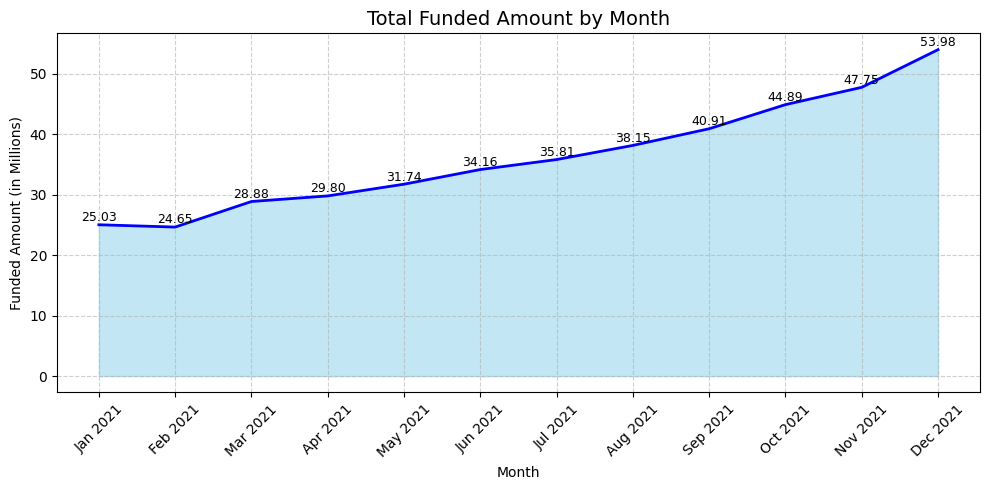

In [16]:
monthly_funded = (
    df.sort_values('issue_date')
    .assign(month_name = lambda x: x['issue_date'].dt.strftime('%b %Y'))
    .groupby('month_name', sort = False)['loan_amount']
    .sum()
    .div(1000000)
    .reset_index(name = 'loan_amount_millions')
)

plt.figure(figsize = (10,5))
plt.fill_between(monthly_funded['month_name'], monthly_funded['loan_amount_millions'], color = 'skyblue', alpha = 0.5)
plt.plot(monthly_funded['month_name'], monthly_funded['loan_amount_millions'], color = 'blue', linewidth = 2)

for i, row in monthly_funded.iterrows():
    plt.text(i, row['loan_amount_millions'] + 0.1, f"{row['loan_amount_millions']:.2f}",
            ha='center', va='bottom', fontsize=9, rotation=0, color='black')

plt.title('Total Funded Amount by Month', fontsize = 14)
plt.xlabel('Month')
plt.ylabel('Funded Amount (in Millions)')
plt.xticks(ticks = range(len(monthly_funded)), labels = monthly_funded['month_name'], rotation = 45)
plt.grid(True, linestyle = '--', alpha = 0.6)
plt.tight_layout()
plt.show()

### Monthly Trend by Issue Date for Total Amount Received

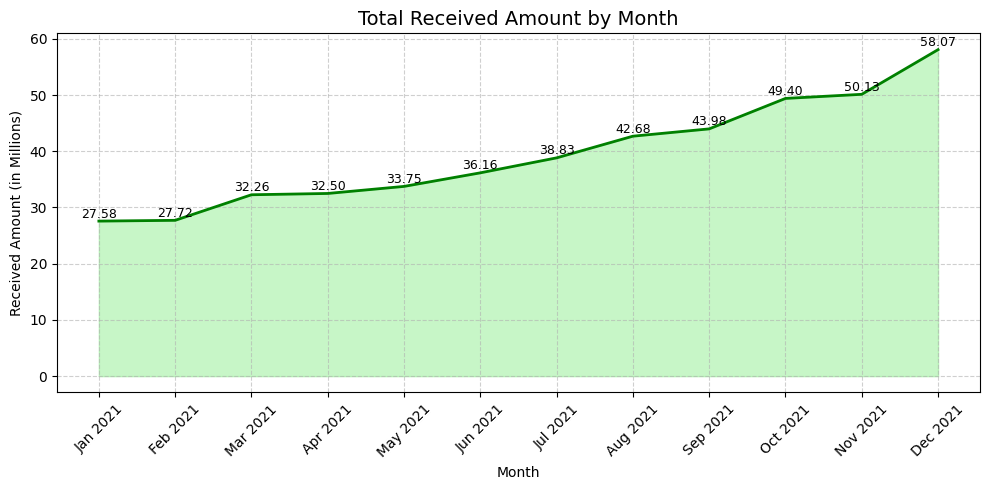

In [17]:
monthly_received = (
    df.sort_values('issue_date')
    .assign(month_name = lambda x: x['issue_date'].dt.strftime('%b %Y'))
    .groupby('month_name', sort = False)['total_payment']
    .sum()
    .div(1000000)
    .reset_index(name = 'total_payment_millions')
)

plt.figure(figsize = (10,5))
plt.fill_between(monthly_received['month_name'], monthly_received['total_payment_millions'], color = 'lightgreen', alpha = 0.5)
plt.plot(monthly_received['month_name'], monthly_received['total_payment_millions'], color = 'green', linewidth = 2)

for i, row in monthly_received.iterrows():
    plt.text(i, row['total_payment_millions'] + 0.1, f"{row['total_payment_millions']:.2f}",
            ha='center', va='bottom', fontsize=9, rotation=0, color='black')

plt.title('Total Received Amount by Month', fontsize = 14)
plt.xlabel('Month')
plt.ylabel('Received Amount (in Millions)')
plt.xticks(ticks = range(len(monthly_received)), labels = monthly_received['month_name'], rotation = 45)
plt.grid(True, linestyle = '--', alpha = 0.6)
plt.tight_layout()
plt.show()

### Monthly Trend by Issue Date for Loan Applications

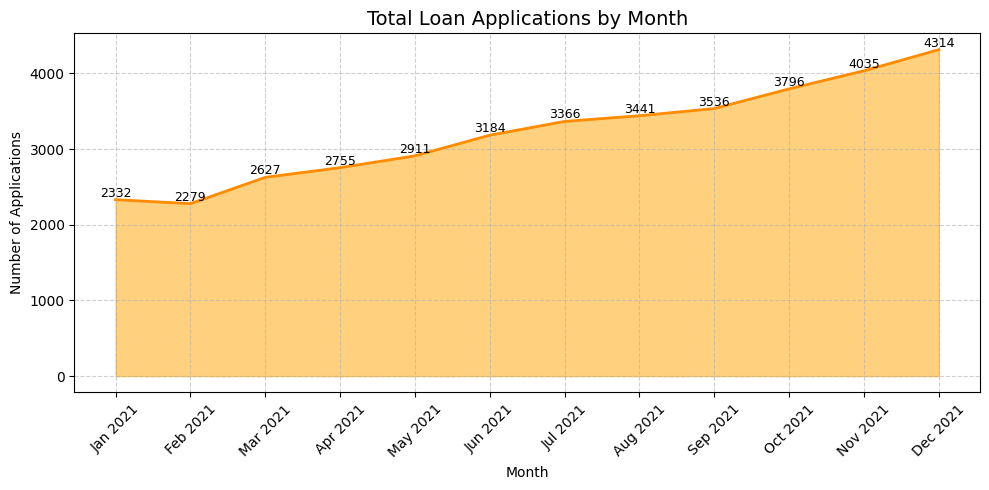

In [18]:
monthly_applications = (
    df.sort_values('issue_date')
    .assign(month_name = lambda x: x['issue_date'].dt.strftime('%b %Y'))
    .groupby('month_name', sort = False)['id']
    .count()
    .reset_index(name = 'loan_application_count')
)

plt.figure(figsize = (10,5))
plt.fill_between(monthly_applications['month_name'], monthly_applications['loan_application_count'], color = 'orange', alpha = 0.5)
plt.plot(monthly_applications['month_name'], monthly_applications['loan_application_count'], color = 'darkorange', linewidth = 2)

for i, row in monthly_applications.iterrows():
    plt.text(i, row['loan_application_count'] + 0.1, f"{row['loan_application_count']}",
            ha='center', va='bottom', fontsize=9, rotation=0, color='black')

plt.title('Total Loan Applications by Month', fontsize = 14)
plt.xlabel('Month')
plt.ylabel('Number of Applications')
plt.xticks(ticks = range(len(monthly_applications)), labels = monthly_applications['month_name'], rotation = 45)
plt.grid(True, linestyle = '--', alpha = 0.6)
plt.tight_layout()
plt.show()

### Regional Analysis by State for Total Funded Amount

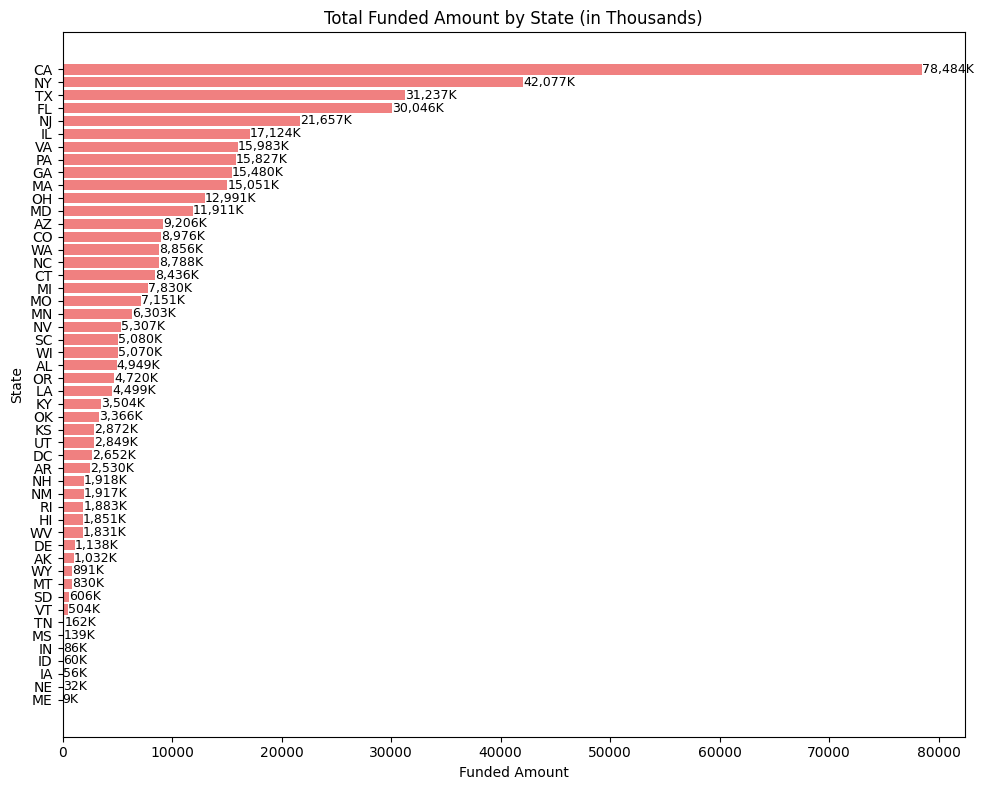

In [19]:
state_funding = df.groupby('address_state')['loan_amount'].sum().sort_values(ascending=True)
state_funding_thousands = state_funding / 1000

plt.figure(figsize = (10, 8))
bars = plt.barh(state_funding_thousands.index, state_funding_thousands.values, color = 'lightcoral')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 10, bar.get_y() + bar.get_height() / 2,
            f"{width:,.0f}K", va = 'center', fontsize = 9)

plt.title('Total Funded Amount by State (in Thousands)')
plt.xlabel('Funded Amount')
plt.ylabel('State')
plt.tight_layout()
plt.show()

### Loan Term Analysis by Total Funded Amount

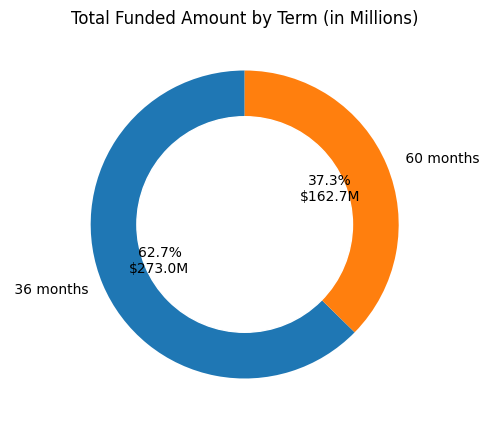

In [20]:
term_funding_millions = df.groupby('term')['loan_amount'].sum() / 1000000

plt.figure(figsize = (5,5))
plt.pie(
    term_funding_millions,
    labels = term_funding_millions.index,
    autopct = lambda p: f"{p:.1f}%\n${p*sum(term_funding_millions)/100:.1f}M",
    startangle = 90,
    wedgeprops = {'width' : 0.4}
)
plt.gca().add_artist(plt.Circle((0,0), 0.70, color = 'white'))
plt.title("Total Funded Amount by Term (in Millions)")
plt.show()

### Employed Length by Total Funded Amount

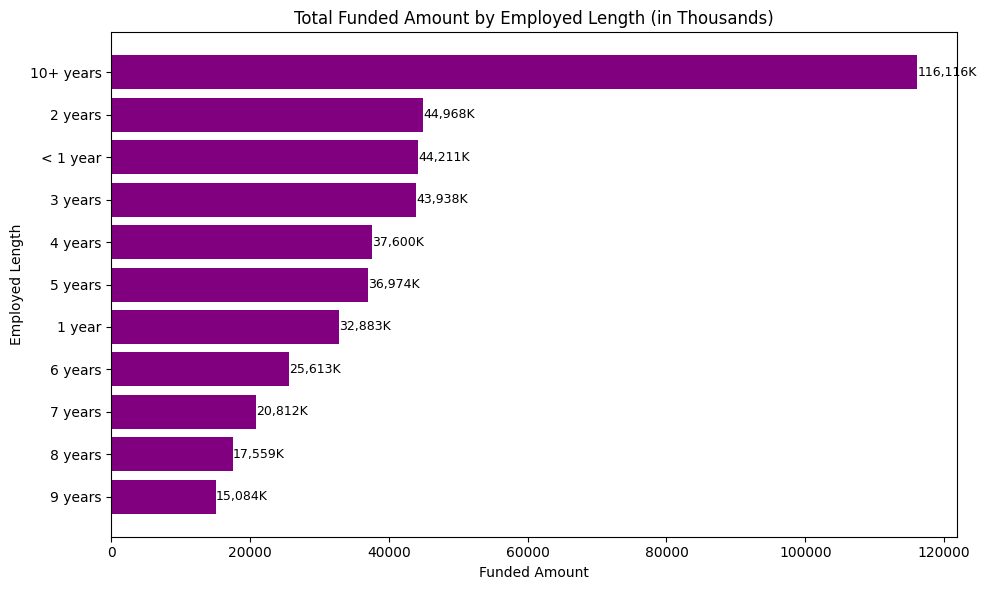

In [21]:
employed_length_thousands = df.groupby('emp_length')['loan_amount'].sum().sort_values() / 1000
plt.figure(figsize = (10, 6))
bars = plt.barh(employed_length_thousands.index, employed_length_thousands.values, color = 'purple')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 5, bar.get_y() + bar.get_height() / 2,
            f"{width:,.0f}K", va = 'center', fontsize = 9)

plt.title('Total Funded Amount by Employed Length (in Thousands)')
plt.xlabel('Funded Amount')
plt.ylabel('Employed Length')
plt.tight_layout()
plt.show()

### Loan Purpose by Total Funded Amount

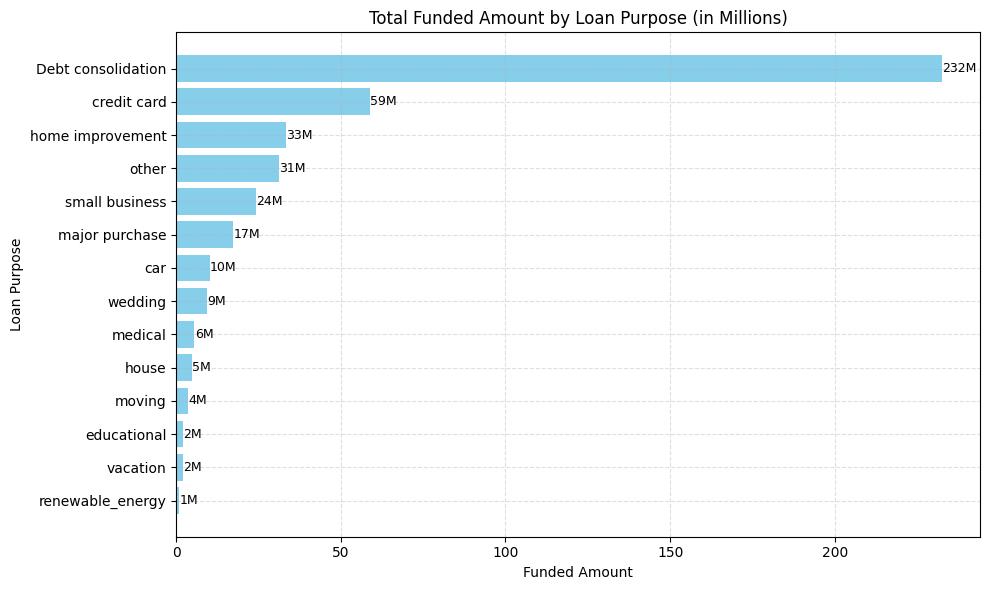

In [22]:
loan_purpose_million = df.groupby('purpose')['loan_amount'].sum().sort_values() / 1000000
plt.figure(figsize = (10, 6))
bars = plt.barh(loan_purpose_million.index, loan_purpose_million.values, color = 'skyblue')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.1, bar.get_y() + bar.get_height() / 2,
            f"{width:,.0f}M", va = 'center', fontsize = 9)

plt.title('Total Funded Amount by Loan Purpose (in Millions)')
plt.xlabel('Funded Amount')
plt.ylabel('Loan Purpose')
plt.grid(axis = 'x', linestyle = '--', alpha = 0.4)
plt.grid(axis = 'y', linestyle = '--', alpha = 0.4)
plt.tight_layout()
plt.show()

### Home Ownership by Total Funded Amount

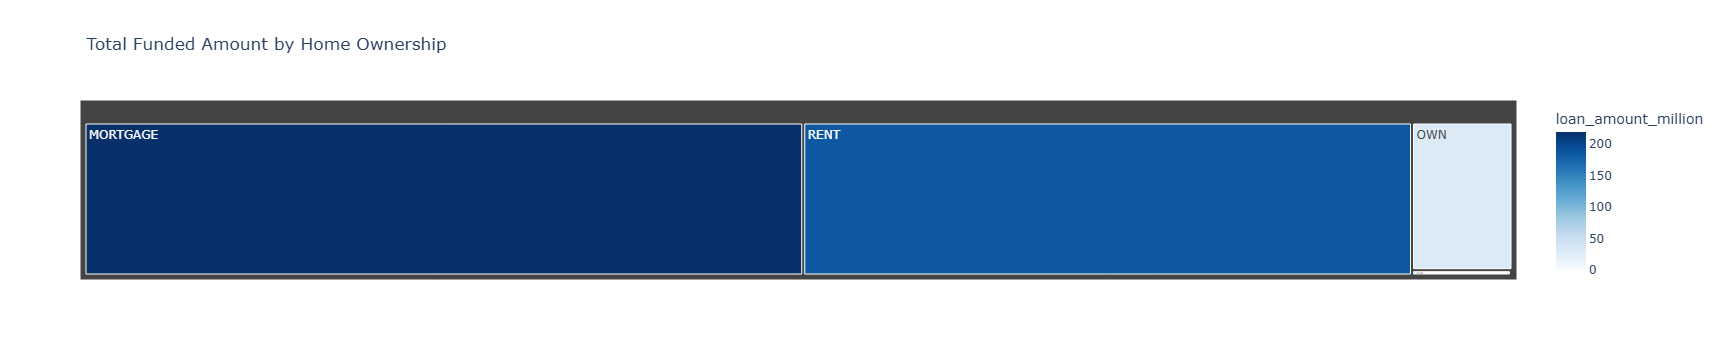

In [24]:
home_funding = df.groupby('home_ownership')['loan_amount'].sum().reset_index()
home_funding['loan_amount_million'] = home_funding['loan_amount'] / 1000000

fig = px.treemap(
    home_funding,
    path = ["home_ownership"],
    values = 'loan_amount_million',
    color = 'loan_amount_million',
    color_continuous_scale = 'Blues',
    title = "Total Funded Amount by Home Ownership "
)

fig.show()